# Análise de Preços — Custo Marginal de Operação (CMO) do SIN 2025

O Custo Marginal de Operação (CMO) é o indicador de preço fundamental do setor elétrico brasileiro. Calculado pelo modelo DECOMP do ONS, ele expressa o custo incremental para atender uma unidade adicional de carga no sistema — ou seja, quanto custa produzir o próximo MWh. O CMO reflete diretamente o estado hidrológico, a disponibilidade de fontes renováveis, a carga térmica despachada e as restrições de transmissão entre subsistemas.

Neste notebook analisamos dois datasets de CMO para 2025:

1. **CMO semanal** (`cmo_semanal2025.csv`): resultado do modelo DECOMP, com valores semanais discriminados por patamar de carga (leve, médio, pesado) e por subsistema. Esse dado captura a visão planejada de custos pelo operador.

2. **CMO semi-horário** (`cmo_semihorario2025.csv`): resolução de 30 minutos, refletindo o preço de curto prazo ao longo de cada dia. Permite analisar dinâmicas intra-diárias de preço e sua relação com variáveis físicas (demanda, geração renovável, hidro).

## Estrutura da Análise

1. **Exploratória** — Estatísticas descritivas, séries temporais, distribuições
2. **CMO em regime estacionário** — Testes de estacionariedade, médias móveis, regime de preços
3. **Padrões mensais típicos** — Sazonalidade de custos, variabilidade intra-mensal, relação com o mix de geração
4. **CMO vs. variáveis físicas** — Correlação com demanda, geração renovável, hidrelétrica e intercâmbio

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", 200)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

from validate_model.pipeline import (
    SINPaths, build_panel,
    load_cmo_semanal, load_cmo_semihorario, load_cmo_horario,
    SUBSYS_ORDER, MESES_PT,
)

paths = SINPaths(root="validate_model", year=2025)
paths.summary()

ROOT: validate_model
Curva carga (4 arquivos): ['validate_model\\data\\demanda_efetiva\\CURVA_CARGA_NORDESTE_2025.csv', 'validate_model\\data\\demanda_efetiva\\CURVA_CARGA_NORTE_2025.csv', 'validate_model\\data\\demanda_efetiva\\CURVA_CARGA_SUDESTE_2025.csv', 'validate_model\\data\\demanda_efetiva\\CURVA_CARGA_SUL_2025.csv']
Previsões   (4 arquivos): ['validate_model\\data\\demanda_esperada\\DEMANDA_NE_2025.csv', 'validate_model\\data\\demanda_esperada\\DEMANDA_N_2025.csv', 'validate_model\\data\\demanda_esperada\\DEMANDA_SE_2025.csv', 'validate_model\\data\\demanda_esperada\\DEMANDA_S_2025.csv']
  Solar               : ✓ validate_model\data\producao_solar\fotovoltaicas_2025.csv
  Eólica              : ✓ validate_model\data\producao_eolica\eolicas_2025.csv
  Nuclear             : ✓ validate_model\data\producao_non_renewable\nuclear_2025.csv
  Térmica             : ✓ validate_model\data\producao_non_renewable\TERMICAS_2025.csv
  Intercâmbio SIN     : ✓ validate_model\data\intercambio\In

## 1. Carregamento dos Dados

Carregamos ambos os datasets de CMO e o painel unificado de variáveis físicas (demanda, geração, intercâmbio) para cruzamento posterior.

In [2]:
# CMO semanal (DECOMP)
cmo_sem = load_cmo_semanal(paths.cmo_semanal_path)
print(f"CMO semanal: {len(cmo_sem):,} linhas, {cmo_sem['id_subsistema'].nunique()} subsistemas")
print(f"  Período: {cmo_sem['din_instante'].min().date()} → {cmo_sem['din_instante'].max().date()}")
display(cmo_sem.head())

# CMO semi-horário (30 min)
cmo_30 = load_cmo_semihorario(paths.cmo_semihorario_path)
print(f"\nCMO semi-horário: {len(cmo_30):,} linhas")
print(f"  Período: {cmo_30['din_instante'].min()} → {cmo_30['din_instante'].max()}")
display(cmo_30.head())

# CMO horário (média das 2 meias-horas)
cmo_h = load_cmo_horario(paths.cmo_semihorario_path)
print(f"\nCMO horário (agregado): {len(cmo_h):,} linhas")

# Painel de variáveis físicas
panel = build_panel(paths)

# Merge CMO horário com painel
panel_cmo = panel.merge(cmo_h, on=["din_instante", "id_subsistema"], how="left")
print(f"\nPainel com CMO: {len(panel_cmo):,} linhas, CMO disponível em {panel_cmo['cmo_h'].notna().sum():,}")

CMO semanal: 208 linhas, 4 subsistemas
  Período: 2025-01-03 → 2025-12-26


,din_instante,id_subsistema,cmo_medio,cmo_leve,cmo_media,cmo_pesada
0,2025-01-03,N,15.44,15.33,15.46,15.68
1,2025-01-03,NE,15.44,15.33,15.46,15.68
2,2025-01-03,S,15.44,15.33,15.46,15.68
3,2025-01-03,SE,15.44,15.33,15.46,15.68
4,2025-01-10,N,40.52,40.22,40.58,40.96



CMO semi-horário: 69,888 linhas
  Período: 2025-01-01 00:00:00 → 2025-12-31 23:30:00


,din_instante,id_subsistema,cmo
0,2025-01-01 00:00:00,NE,12.32
1,2025-01-01 00:00:00,N,12.34
2,2025-01-01 00:00:00,SE,12.34
3,2025-01-01 00:00:00,S,12.34
4,2025-01-01 00:30:00,NE,12.08



CMO horário (agregado): 34,944 linhas
Carregando demanda efetiva...
  ✓ 28,512 linhas
Carregando geração por fonte...
  ✓ solar: 29,664 linhas
  ✓ wind: 29,664 linhas
  ✓ nuclear: 7,416 linhas
  ✓ thermal: 29,664 linhas
  ✓ hydro: 29,664 linhas
  Total de gerações: 126,072 linhas
Carregando intercâmbio interno...
  ✓ 33,600 linhas

Painel montado: 29,664 linhas
Subsistemas: ['N', 'NE', 'S', 'SE']
Período: 2025-01-01 00:00:00 → 2025-11-05 23:00:00

Painel com CMO: 29,664 linhas, CMO disponível em 29,568


## 2. Análise Exploratória do CMO

### 2.1 Estatísticas Descritivas

O CMO semanal do DECOMP apresenta valores por patamar de carga:
- **Leve**: madrugada e finais de semana (demanda baixa)
- **Médio**: horário comercial (demanda típica)
- **Pesado**: pico de consumo (18h–21h)

A dispersão entre patamares revela o "spread de pico" do sistema.

In [3]:
# Estatísticas do CMO semanal por subsistema
cmo_cols = ["cmo_medio", "cmo_leve", "cmo_media", "cmo_pesada"]

for ss in SUBSYS_ORDER:
    sub = cmo_sem[cmo_sem["id_subsistema"] == ss][cmo_cols]
    print(f"\n{'='*50}")
    print(f"  CMO Semanal — Subsistema {ss} (R$/MWh)")
    print(f"{'='*50}")
    display(sub.describe().round(2))

# Spread entre patamares
cmo_sem["spread_pesada_leve"] = cmo_sem["cmo_pesada"] - cmo_sem["cmo_leve"]
print("\nSpread médio pesada − leve por subsistema (R$/MWh):")
display(cmo_sem.groupby("id_subsistema")["spread_pesada_leve"].describe().round(2))


  CMO Semanal — Subsistema N (R$/MWh)


,cmo_medio,cmo_leve,cmo_media,cmo_pesada
count,52.00,52.00,52.00,52.00
mean,194.82,187.87,193.51,212.17
std,140.20,135.04,138.34,163.17
min,0.00,0.00,0.00,0.00
25%,13.47,13.36,13.50,13.68
50%,270.96,269.02,271.48,274.90
75%,316.81,297.35,306.58,325.79
max,353.03,344.11,351.32,555.69



  CMO Semanal — Subsistema NE (R$/MWh)


,cmo_medio,cmo_leve,cmo_media,cmo_pesada
count,52.00,52.00,52.00,52.00
mean,188.14,179.54,193.07,197.38
std,135.66,135.41,138.11,141.19
min,0.00,0.00,0.00,0.00
25%,13.47,5.60,13.50,13.68
50%,254.31,242.42,263.25,268.85
75%,304.02,297.35,306.58,315.21
max,349.82,344.11,351.32,357.46



  CMO Semanal — Subsistema SE (R$/MWh)


,cmo_medio,cmo_leve,cmo_media,cmo_pesada
count,52.00,52.00,52.00,52.00
mean,248.07,240.29,252.18,259.08
std,100.10,101.22,99.26,101.67
min,7.57,7.47,7.60,7.69
25%,211.45,208.27,225.64,233.86
50%,281.62,274.77,281.54,291.53
75%,317.12,310.22,318.93,326.55
max,397.17,388.79,400.75,406.34



  CMO Semanal — Subsistema S (R$/MWh)


,cmo_medio,cmo_leve,cmo_media,cmo_pesada
count,52.00,52.00,52.00,52.00
mean,251.20,240.29,258.70,263.33
std,100.73,101.22,101.66,103.69
min,7.57,7.47,7.60,7.69
25%,211.79,208.27,235.39,236.67
50%,292.13,274.77,297.60,304.46
75%,322.05,310.22,325.78,332.80
max,397.17,388.79,400.75,406.34



Spread médio pesada − leve por subsistema (R$/MWh):


,count,mean,std,min,25%,50%,75%,max
id_subsistema,,,,,,,,
N,52.0,24.30,62.82,0.00,0.17,6.51,13.43,278.41
NE,52.0,17.83,46.71,0.00,0.32,6.98,13.43,312.48
S,52.0,23.04,31.67,0.22,7.71,13.26,21.49,150.26
SE,52.0,18.79,25.66,0.22,7.71,13.26,19.67,135.52


### 2.2 Evolução Temporal do CMO Semanal

Série temporal do CMO médio semanal para cada subsistema, com bandas de patamar (leve a pesado).

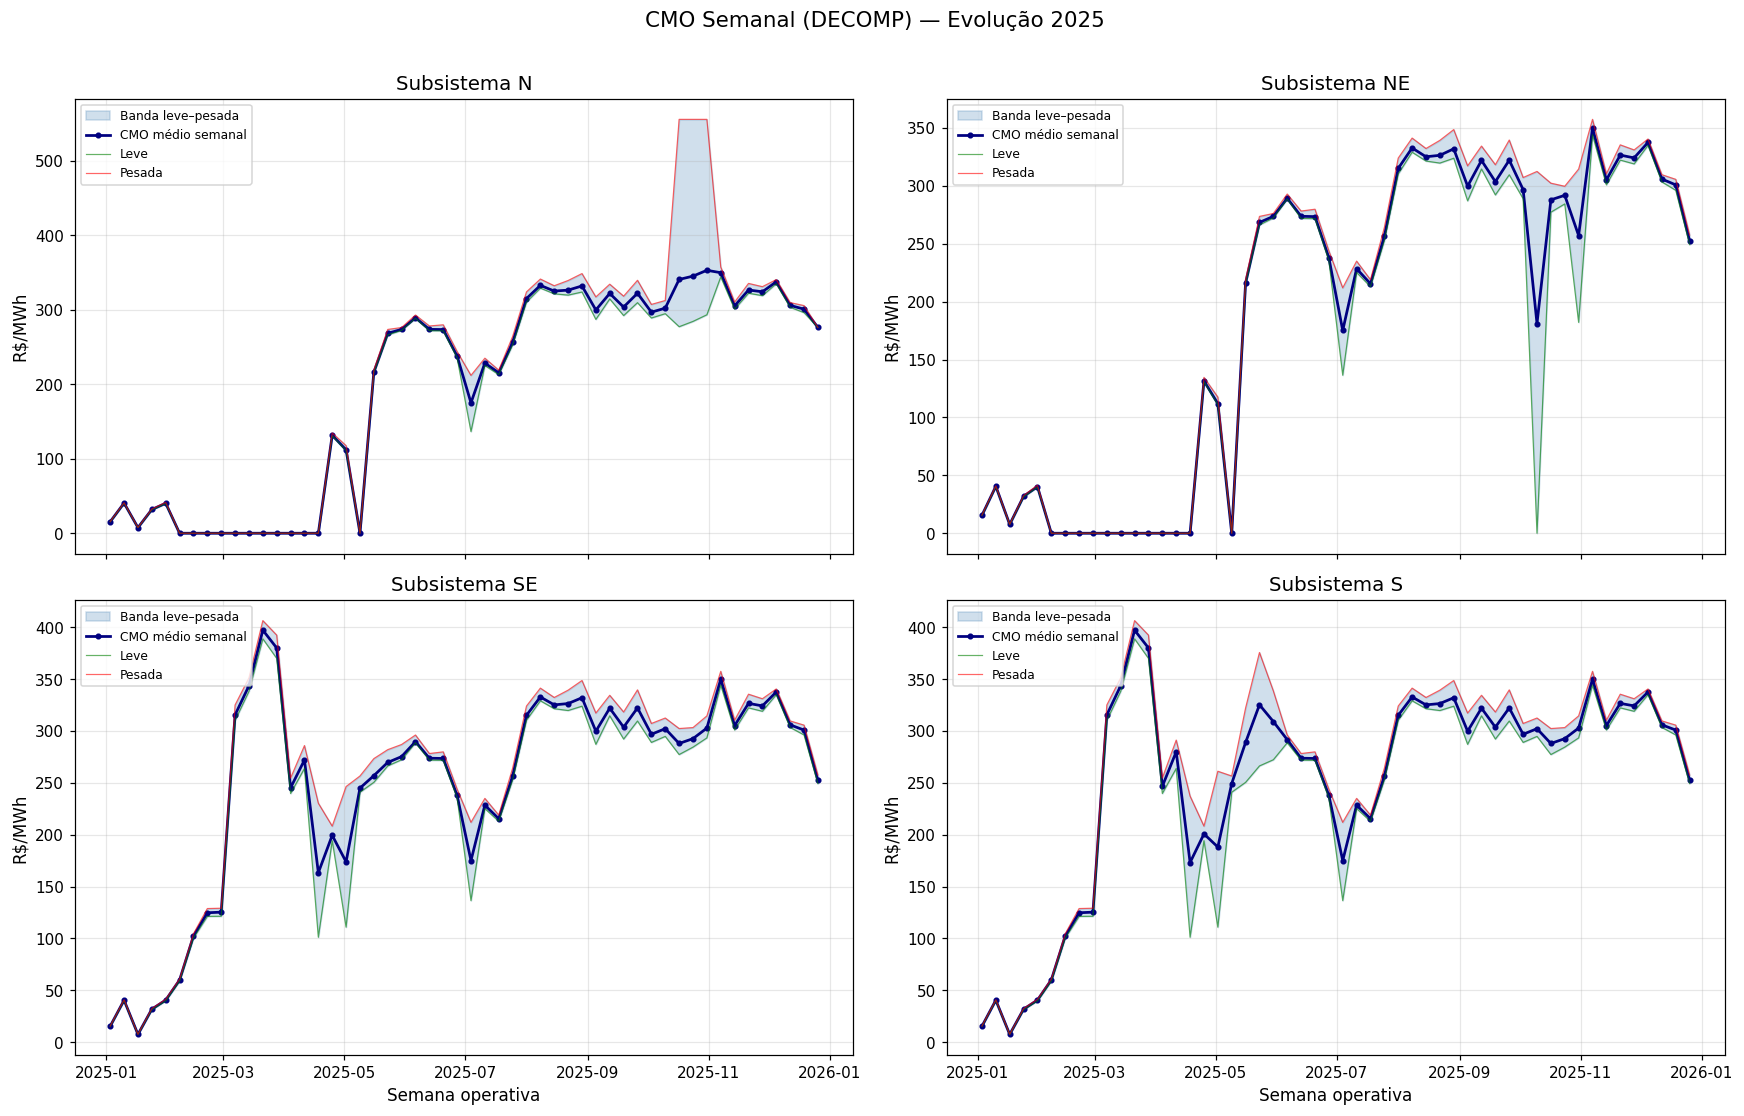

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
for ax, ss in zip(axes.flat, SUBSYS_ORDER):
    sub = cmo_sem[cmo_sem["id_subsistema"] == ss].sort_values("din_instante")
    t = sub["din_instante"]

    ax.fill_between(t, sub["cmo_leve"], sub["cmo_pesada"],
                    alpha=0.25, color="steelblue", label="Banda leve–pesada")
    ax.plot(t, sub["cmo_medio"], marker="o", markersize=3,
            linewidth=1.8, color="navy", label="CMO médio semanal")
    ax.plot(t, sub["cmo_leve"], linewidth=0.8, alpha=0.6, color="green", label="Leve")
    ax.plot(t, sub["cmo_pesada"], linewidth=0.8, alpha=0.6, color="red", label="Pesada")

    ax.set_title(f"Subsistema {ss}")
    ax.set_ylabel("R$/MWh")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc="upper left")

for ax in axes[1]:
    ax.set_xlabel("Semana operativa")
fig.suptitle("CMO Semanal (DECOMP) — Evolução 2025", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### 2.3 CMO Semi-horário: Perfil Intra-diário

O CMO com resolução de 30 minutos revela a dinâmica de preços ao longo do dia. Em geral, preços são mais baixos na madrugada (demanda baixa, muita eólica) e mais altos no pico (18h–21h).

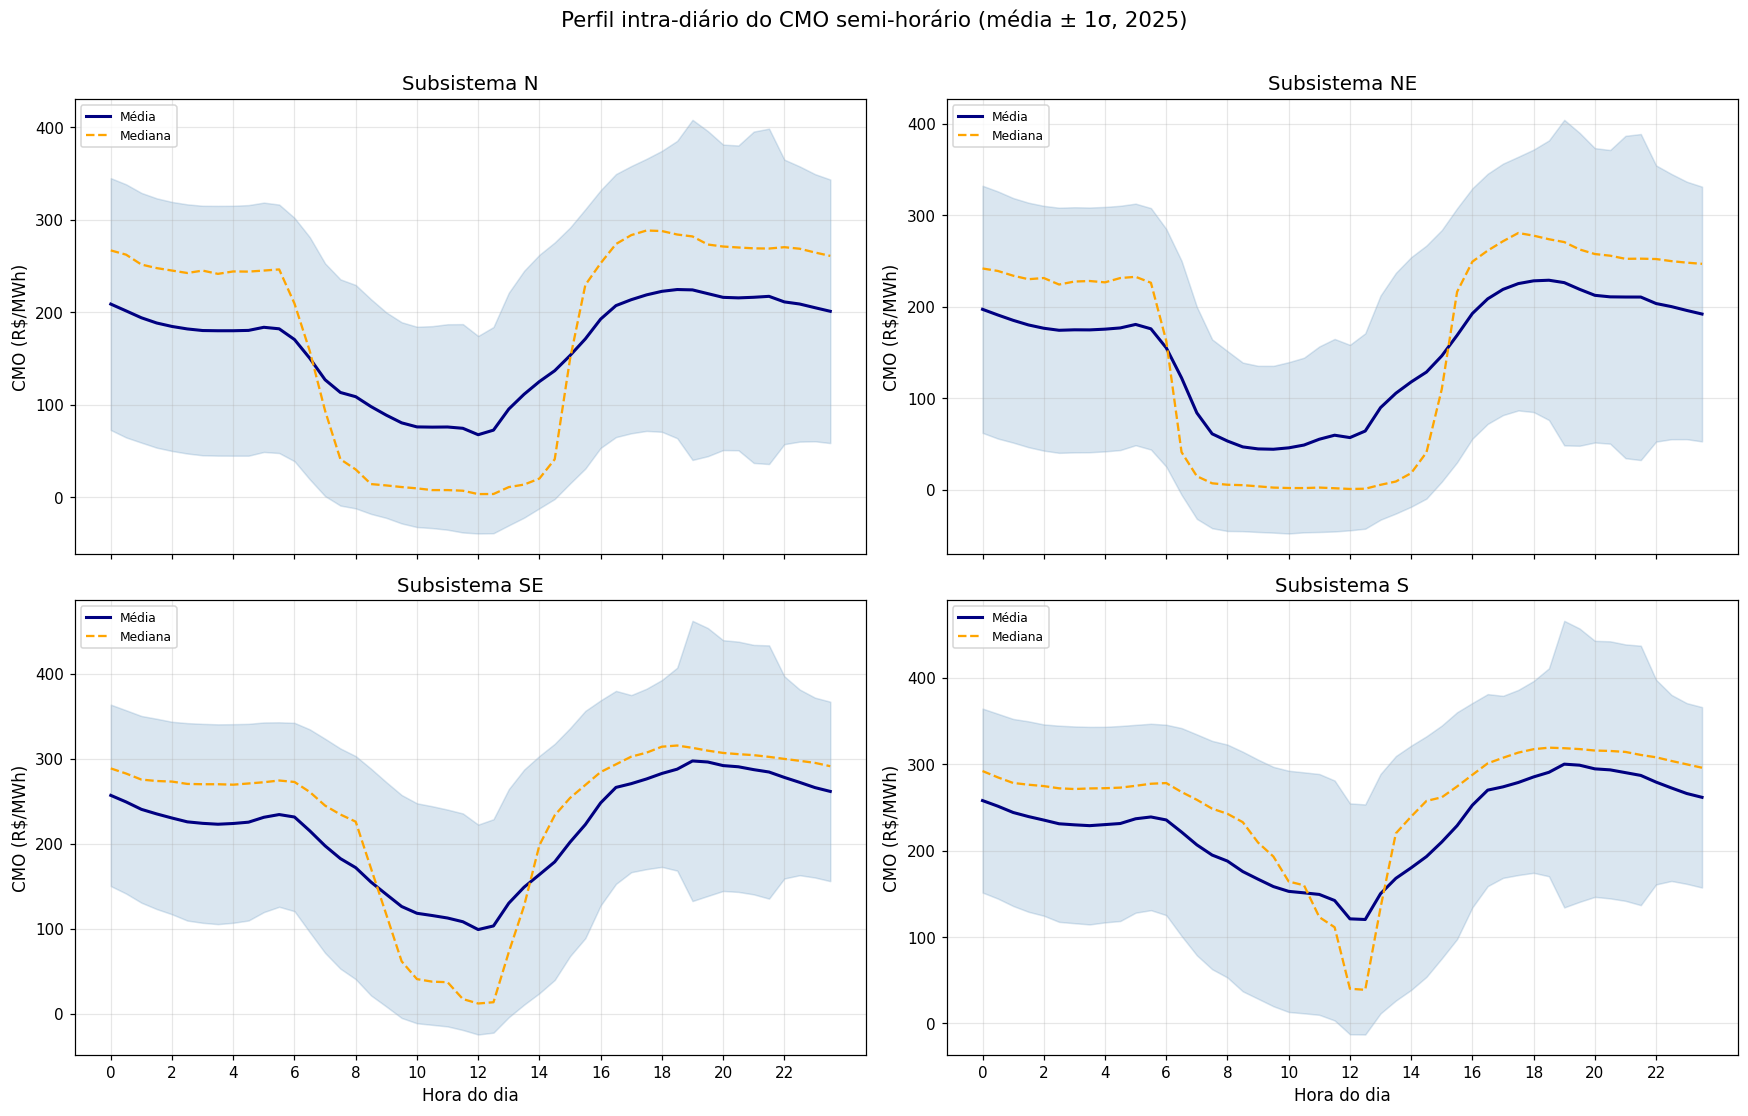

In [5]:
cmo_30["hora"] = cmo_30["din_instante"].dt.hour + cmo_30["din_instante"].dt.minute / 60

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
for ax, ss in zip(axes.flat, SUBSYS_ORDER):
    sub = cmo_30[cmo_30["id_subsistema"] == ss]
    hourly_stats = sub.groupby("hora")["cmo"].agg(["mean", "std", "median"])

    ax.fill_between(hourly_stats.index,
                    hourly_stats["mean"] - hourly_stats["std"],
                    hourly_stats["mean"] + hourly_stats["std"],
                    alpha=0.2, color="steelblue")
    ax.plot(hourly_stats.index, hourly_stats["mean"],
            linewidth=2, color="navy", label="Média")
    ax.plot(hourly_stats.index, hourly_stats["median"],
            linewidth=1.5, linestyle="--", color="orange", label="Mediana")

    ax.set_title(f"Subsistema {ss}")
    ax.set_ylabel("CMO (R$/MWh)")
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[1]:
    ax.set_xlabel("Hora do dia")
fig.suptitle("Perfil intra-diário do CMO semi-horário (média ± 1σ, 2025)", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### 2.4 Heatmap do CMO Semi-horário

Mapa de calor dia × hora para visualizar eventos de preço extremo e sazonalidade.

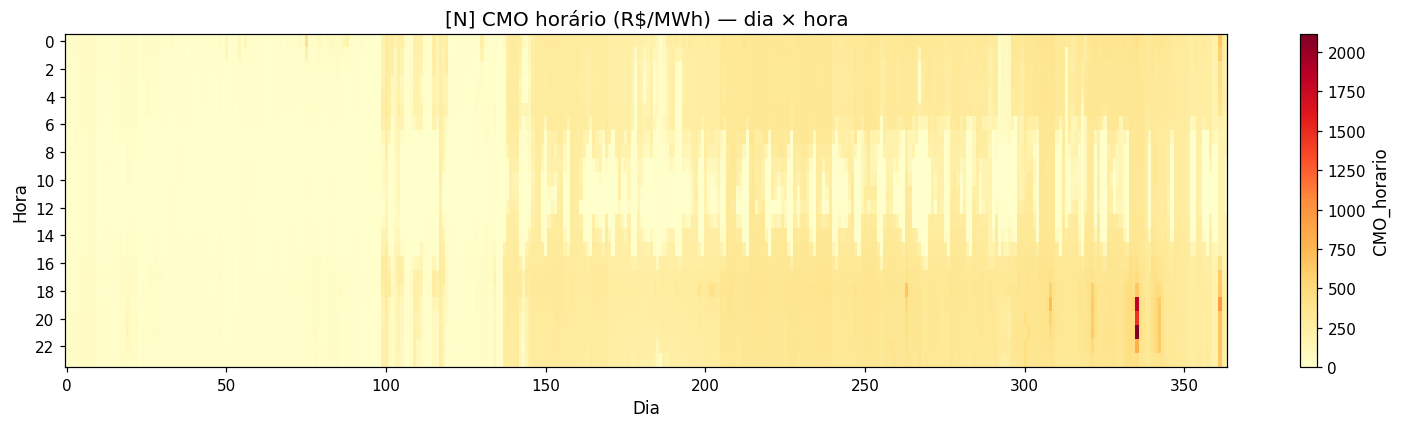

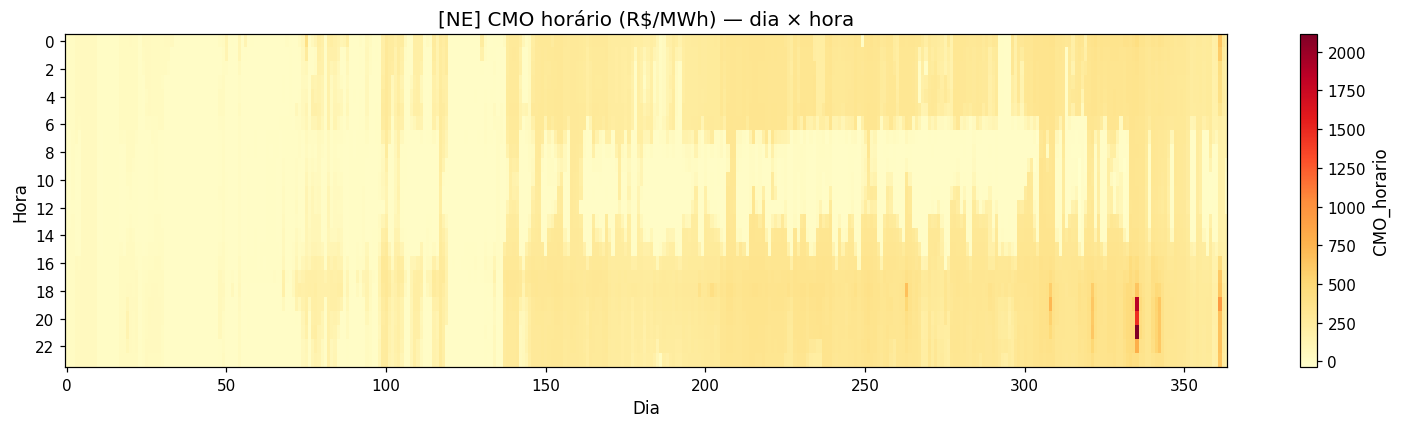

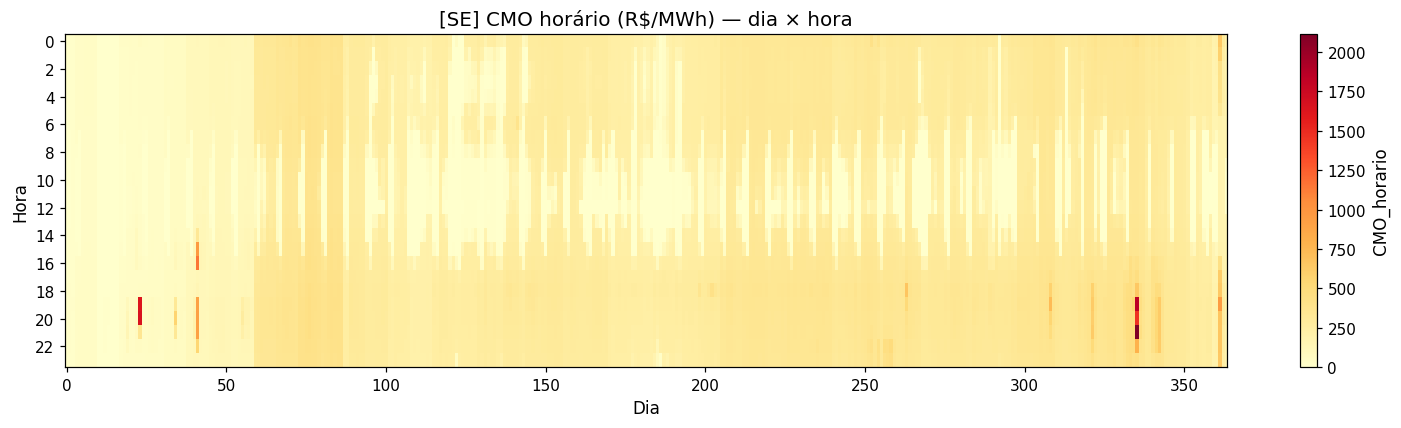

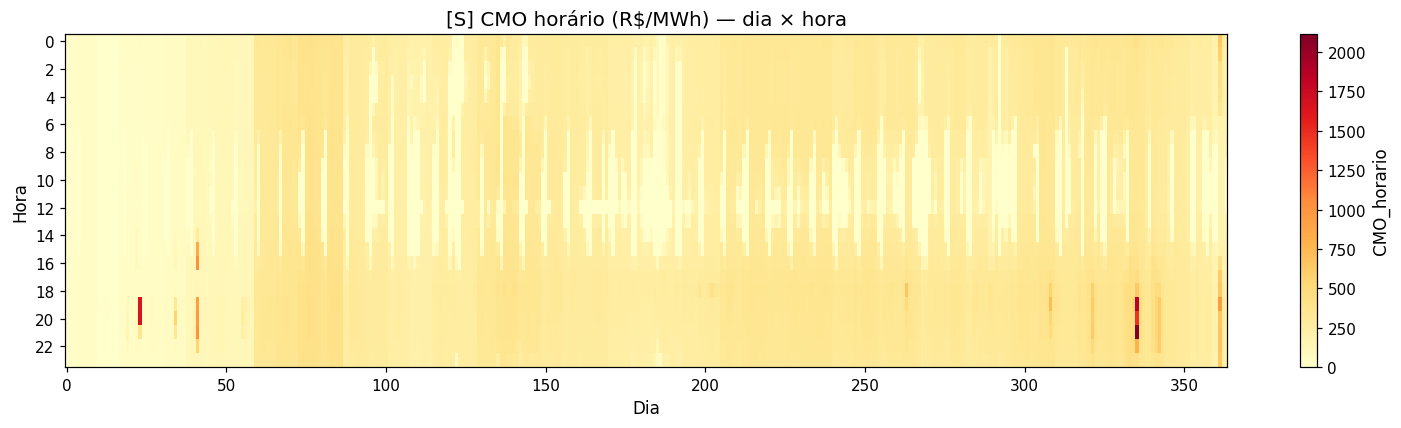

In [6]:
from validate_model.pipeline import heatmap_day_hour

cmo_h_for_heatmap = cmo_h.copy()
cmo_h_for_heatmap.rename(columns={"cmo_h": "cmo"}, inplace=True)

for ss in SUBSYS_ORDER:
    heatmap_day_hour(cmo_h_for_heatmap.rename(columns={"cmo": "CMO_horario"}),
                     "CMO_horario", ss,
                     "CMO horário (R$/MWh) — dia × hora",
                     cmap="YlOrRd")

### 2.5 Distribuição de Preços e Diferenças entre Subsistemas

Histogramas e boxplots mostrando a forma da distribuição de preços e se há diferenciação regional significativa.

C:\Users\joaof\AppData\Local\Temp\ipykernel_12788\1464606943.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_box, labels=SUBSYS_ORDER, patch_artist=True, showfliers=False)


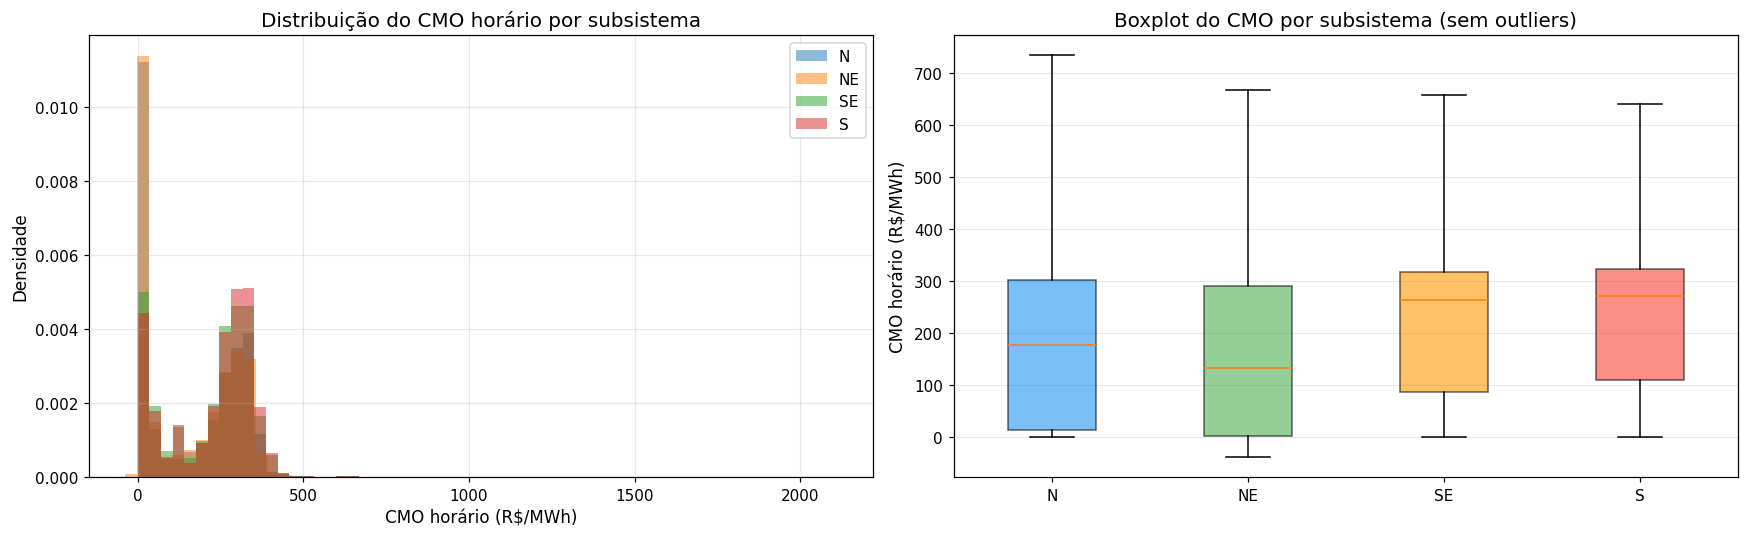

Diferença média de CMO entre subsistemas (R$/MWh):


,N,NE,SE,S
N,0.00,12.11,-53.07,-63.35
NE,-12.11,0.00,-65.18,-75.46
SE,53.07,65.18,0.00,-10.28
S,63.35,75.46,10.28,0.00


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma
ax = axes[0]
for ss in SUBSYS_ORDER:
    sub = cmo_h[cmo_h["id_subsistema"] == ss]["cmo_h"].dropna()
    ax.hist(sub, bins=60, alpha=0.5, label=ss, density=True)
ax.set_xlabel("CMO horário (R$/MWh)")
ax.set_ylabel("Densidade")
ax.set_title("Distribuição do CMO horário por subsistema")
ax.legend()
ax.grid(True, alpha=0.3)

# Boxplot por subsistema
ax = axes[1]
data_box = [cmo_h[cmo_h["id_subsistema"] == ss]["cmo_h"].dropna().values for ss in SUBSYS_ORDER]
bp = ax.boxplot(data_box, labels=SUBSYS_ORDER, patch_artist=True, showfliers=False)
colors = ["#2196F3", "#4CAF50", "#FF9800", "#F44336"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("CMO horário (R$/MWh)")
ax.set_title("Boxplot do CMO por subsistema (sem outliers)")
ax.grid(True, alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

# Estatísticas de diferença entre subsistemas
print("Diferença média de CMO entre subsistemas (R$/MWh):")
piv = cmo_h.pivot_table(index="din_instante", columns="id_subsistema", values="cmo_h")
if len(piv.columns) > 1:
    diff_matrix = pd.DataFrame(index=SUBSYS_ORDER, columns=SUBSYS_ORDER, dtype=float)
    for s1 in SUBSYS_ORDER:
        for s2 in SUBSYS_ORDER:
            if s1 in piv.columns and s2 in piv.columns:
                diff_matrix.loc[s1, s2] = (piv[s1] - piv[s2]).mean()
    display(diff_matrix.round(2))

## 3. CMO em Regime Estacionário

A estacionariedade do CMO é relevante para modelagem econométrica e para a definição de cenários de planejamento. Um processo estacionário tem média e variância constantes no tempo, o que simplifica a projeção de custos futuros.

Aplicamos:
- **Teste ADF (Augmented Dickey-Fuller)**: testa $H_0$: raiz unitária (não-estacionário). Se $p < 0.05$, rejeitamos $H_0$ e a série é estacionária.
- **Estatísticas de janela móvel**: média e desvio-padrão em janelas deslizantes para identificar mudanças de regime.
- **Classificação de regimes de preço**: limites para categorizar horas em preço baixo, normal e alto.

In [8]:
from statsmodels.tsa.stattools import adfuller

print("=" * 70)
print("TESTE ADF (Augmented Dickey-Fuller) — Estacionariedade do CMO")
print("=" * 70)
print("H0: a série possui raiz unitária (não-estacionária)")
print("Rejeitar H0 (p < 0.05) → evidência de estacionariedade\n")

adf_results = []
for ss in SUBSYS_ORDER:
    series = cmo_h[cmo_h["id_subsistema"] == ss].sort_values("din_instante")["cmo_h"].dropna()
    if len(series) < 50:
        print(f"[{ss}] série muito curta ({len(series)} pontos)")
        continue

    result = adfuller(series, autolag="AIC")
    stat, pval, lags, nobs = result[0], result[1], result[2], result[3]
    conclusao = "ESTACIONÁRIA" if pval < 0.05 else "NÃO-ESTACIONÁRIA"

    print(f"[{ss}] ADF stat = {stat:.4f}, p-valor = {pval:.6f}, "
          f"lags = {lags}, obs = {nobs} → {conclusao}")
    adf_results.append({"subsistema": ss, "adf_stat": stat, "p_valor": pval,
                        "lags": lags, "n_obs": nobs, "conclusao": conclusao})

adf_df = pd.DataFrame(adf_results)
display(adf_df)

TESTE ADF (Augmented Dickey-Fuller) — Estacionariedade do CMO
H0: a série possui raiz unitária (não-estacionária)
Rejeitar H0 (p < 0.05) → evidência de estacionariedade

[N] ADF stat = -4.4069, p-valor = 0.000289, lags = 29, obs = 8706 → ESTACIONÁRIA
[NE] ADF stat = -4.7536, p-valor = 0.000067, lags = 29, obs = 8706 → ESTACIONÁRIA
[SE] ADF stat = -6.1342, p-valor = 0.000000, lags = 31, obs = 8704 → ESTACIONÁRIA
[S] ADF stat = -6.5493, p-valor = 0.000000, lags = 31, obs = 8704 → ESTACIONÁRIA


,subsistema,adf_stat,p_valor,lags,n_obs,conclusao
0,N,-4.406873,2.886285e-04,29,8706,ESTACIONÁRIA
1,NE,-4.753643,6.664993e-05,29,8706,ESTACIONÁRIA
2,SE,-6.134172,8.263532e-08,31,8704,ESTACIONÁRIA
3,S,-6.549300,8.934185e-09,31,8704,ESTACIONÁRIA


### 3.1 Médias Móveis e Identificação de Regimes

Visualizamos a evolução da média e desvio-padrão em janela deslizante de 7 dias (168 horas) para identificar mudanças de regime ao longo do ano.

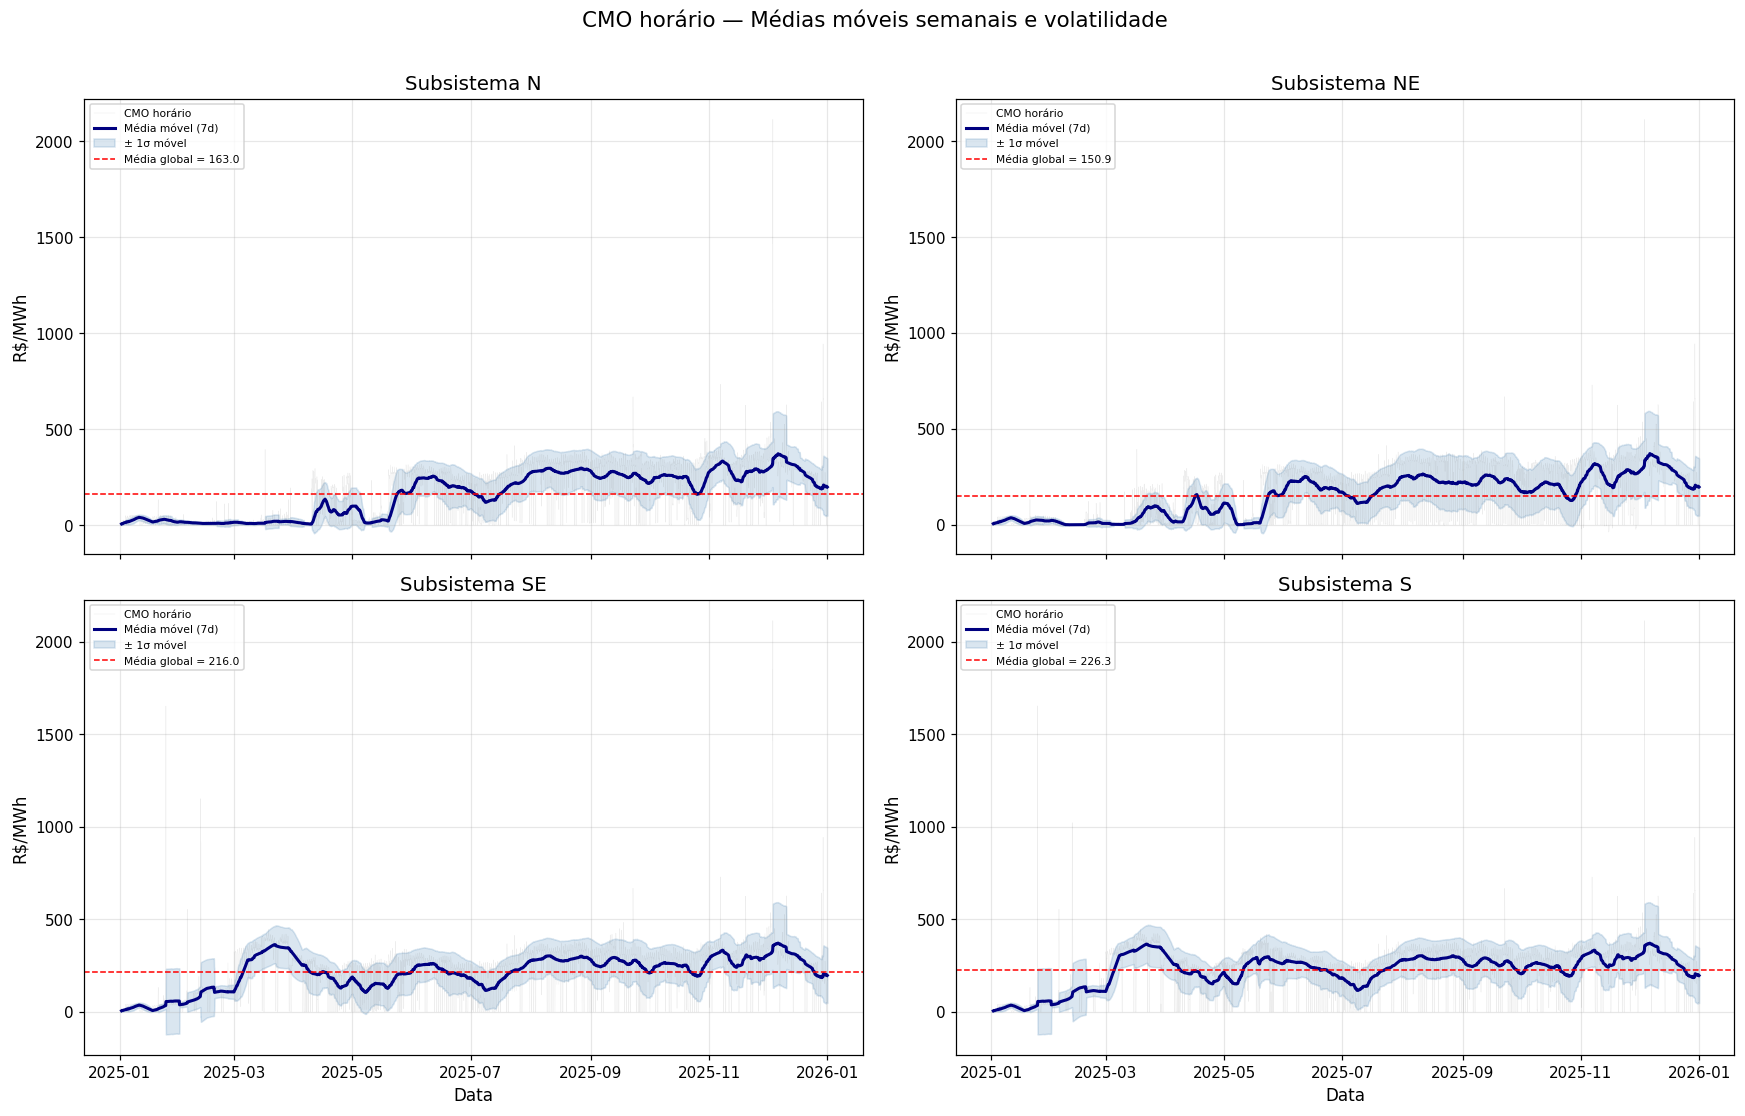

In [9]:
WINDOW = 168  # 7 dias em horas

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)
for ax, ss in zip(axes.flat, SUBSYS_ORDER):
    sub = (cmo_h[cmo_h["id_subsistema"] == ss]
           .sort_values("din_instante")
           .set_index("din_instante")["cmo_h"])

    rolling_mean = sub.rolling(WINDOW, min_periods=24).mean()
    rolling_std = sub.rolling(WINDOW, min_periods=24).std()
    global_mean = sub.mean()

    ax.plot(sub.index, sub.values, alpha=0.15, linewidth=0.3, color="gray", label="CMO horário")
    ax.plot(rolling_mean.index, rolling_mean.values, linewidth=2,
            color="navy", label=f"Média móvel ({WINDOW//24}d)")
    ax.fill_between(rolling_mean.index,
                    rolling_mean.values - rolling_std.values,
                    rolling_mean.values + rolling_std.values,
                    alpha=0.2, color="steelblue", label="± 1σ móvel")
    ax.axhline(global_mean, linestyle="--", color="red", linewidth=1,
               label=f"Média global = {global_mean:.1f}")

    ax.set_title(f"Subsistema {ss}")
    ax.set_ylabel("R$/MWh")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper left")

for ax in axes[1]:
    ax.set_xlabel("Data")
fig.suptitle("CMO horário — Médias móveis semanais e volatilidade", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### 3.2 Classificação de Regimes de Preço

Classificamos cada hora em três regimes baseados em percentis da distribuição:
- **Preço baixo** (< P25): tipicamente horas de abundância renovável/hídrica
- **Preço normal** (P25–P75): operação de rotina
- **Preço alto** (> P75): estresse no sistema, despacho térmico elevado

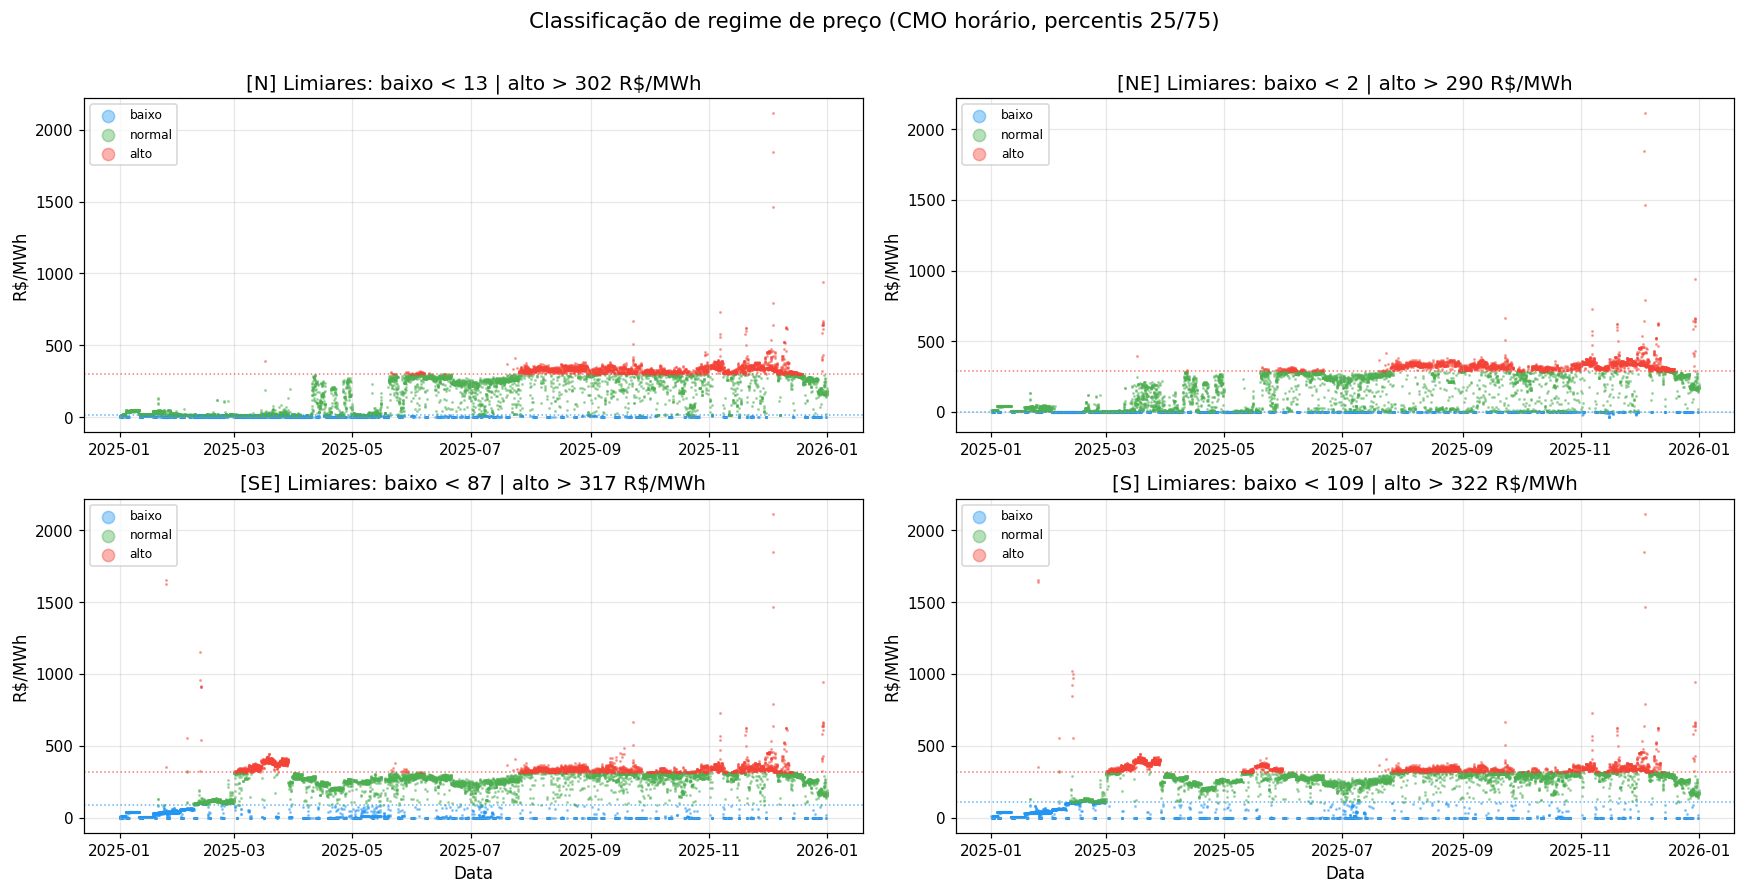

Proporção de horas em cada regime de preço:
  [N] Baixo: 25.0%  |  Normal: 50.0%  |  Alto: 25.0%
  [NE] Baixo: 25.0%  |  Normal: 50.0%  |  Alto: 25.0%
  [SE] Baixo: 25.0%  |  Normal: 50.0%  |  Alto: 25.0%
  [S] Baixo: 25.0%  |  Normal: 50.0%  |  Alto: 25.0%


In [10]:
def classify_price_regime(series, q_low=0.25, q_high=0.75):
    """Classifica valores em regimes: baixo, normal, alto."""
    low_thresh = series.quantile(q_low)
    high_thresh = series.quantile(q_high)
    regime = pd.Series("normal", index=series.index)
    regime[series <= low_thresh] = "baixo"
    regime[series >= high_thresh] = "alto"
    return regime, low_thresh, high_thresh

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
regime_colors = {"baixo": "#2196F3", "normal": "#4CAF50", "alto": "#F44336"}

for ax, ss in zip(axes.flat, SUBSYS_ORDER):
    sub = cmo_h[cmo_h["id_subsistema"] == ss].sort_values("din_instante").copy()
    sub["regime"], low_t, high_t = classify_price_regime(sub["cmo_h"])

    for regime, color in regime_colors.items():
        mask = sub["regime"] == regime
        ax.scatter(sub.loc[mask, "din_instante"], sub.loc[mask, "cmo_h"],
                   s=1, alpha=0.4, color=color, label=regime)

    ax.axhline(low_t, linestyle=":", color="#2196F3", linewidth=1, alpha=0.7)
    ax.axhline(high_t, linestyle=":", color="#F44336", linewidth=1, alpha=0.7)
    ax.set_title(f"[{ss}] Limiares: baixo < {low_t:.0f} | alto > {high_t:.0f} R$/MWh")
    ax.set_ylabel("R$/MWh")
    ax.legend(fontsize=8, markerscale=8)
    ax.grid(True, alpha=0.3)

for ax in axes[1]:
    ax.set_xlabel("Data")
fig.suptitle("Classificação de regime de preço (CMO horário, percentis 25/75)", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

# Proporção de horas em cada regime
print("Proporção de horas em cada regime de preço:")
for ss in SUBSYS_ORDER:
    sub = cmo_h[cmo_h["id_subsistema"] == ss]["cmo_h"].dropna()
    regime, _, _ = classify_price_regime(sub)
    counts = regime.value_counts(normalize=True) * 100
    print(f"  [{ss}] Baixo: {counts.get('baixo', 0):.1f}%  |  "
          f"Normal: {counts.get('normal', 0):.1f}%  |  "
          f"Alto: {counts.get('alto', 0):.1f}%")

## 4. Padrões Mensais Típicos de Custo Operacional

O custo marginal apresenta forte sazonalidade no Brasil, reflexo direto do ciclo hidrológico: no período chuvoso (Nov–Mar), reservatórios cheios mantêm CMO baixo; no período seco (Jun–Out), a necessidade de térmicas eleva o preço. Além da sazonalidade mensal, há variação significativa entre meses dentro de cada estação, influenciada por eventos climáticos, manutenções programadas e picos de demanda.

C:\Users\joaof\AppData\Local\Temp\ipykernel_12788\300091219.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_month, labels=[MESES_PT.get(m, m) for m in months_present],
C:\Users\joaof\AppData\Local\Temp\ipykernel_12788\300091219.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_month, labels=[MESES_PT.get(m, m) for m in months_present],
C:\Users\joaof\AppData\Local\Temp\ipykernel_12788\300091219.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_month, labels=[MESES_PT.get(m, m) for m in months_present],
C:\Users\joaof\AppData\Local\Temp\

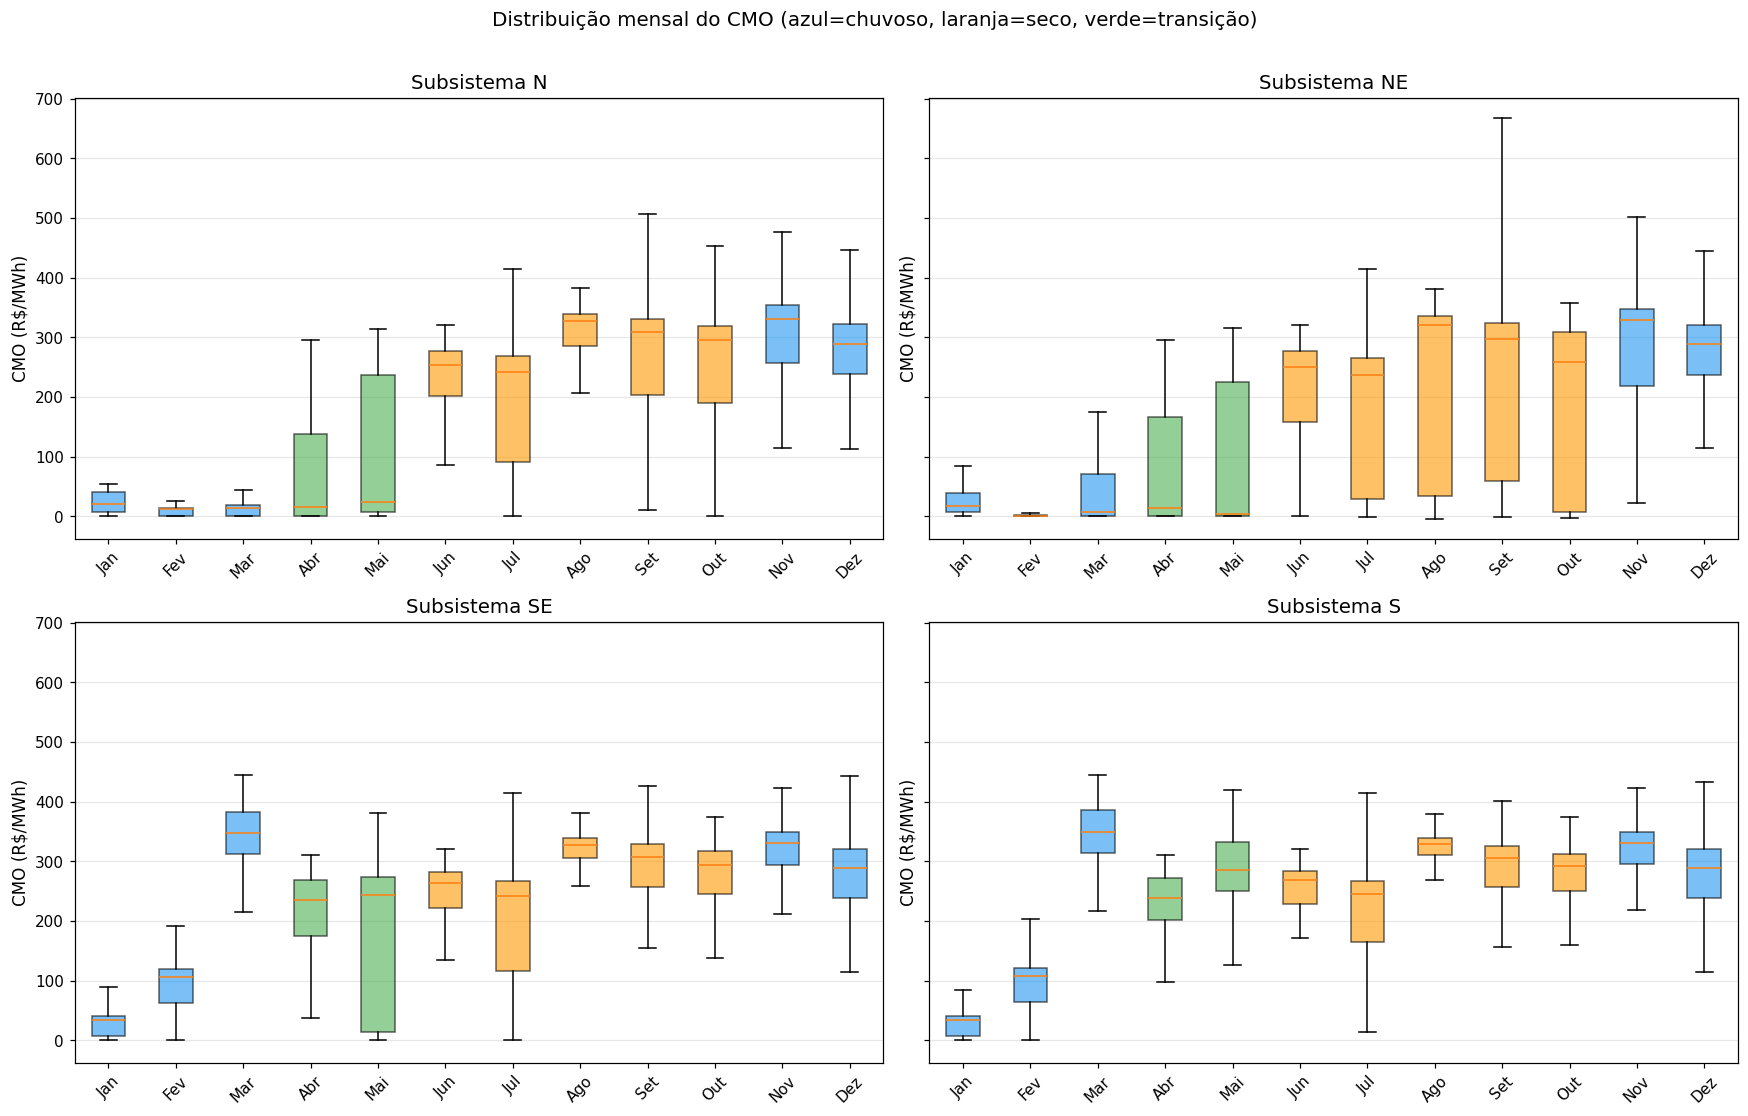

In [11]:
cmo_h_m = cmo_h.copy()
cmo_h_m["mes"] = cmo_h_m["din_instante"].dt.month

# --- Boxplot mensal por subsistema ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
for ax, ss in zip(axes.flat, SUBSYS_ORDER):
    sub = cmo_h_m[cmo_h_m["id_subsistema"] == ss]
    months_present = sorted(sub["mes"].unique())

    data_by_month = [sub[sub["mes"] == m]["cmo_h"].dropna().values for m in months_present]
    bp = ax.boxplot(data_by_month, labels=[MESES_PT.get(m, m) for m in months_present],
                    patch_artist=True, showfliers=False)

    for i, patch in enumerate(bp["boxes"]):
        month = months_present[i]
        if month in [6, 7, 8, 9, 10]:
            patch.set_facecolor("#FF9800")
            patch.set_alpha(0.6)
        elif month in [11, 12, 1, 2, 3]:
            patch.set_facecolor("#2196F3")
            patch.set_alpha(0.6)
        else:
            patch.set_facecolor("#4CAF50")
            patch.set_alpha(0.6)

    ax.set_title(f"Subsistema {ss}")
    ax.set_ylabel("CMO (R$/MWh)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3, axis="y")

fig.suptitle("Distribuição mensal do CMO (azul=chuvoso, laranja=seco, verde=transição)",
             fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

### 4.1 Custo Médio Mensal por Subsistema

Evolução mês a mês do custo médio e mediano, com comparação entre subsistemas.


  CMO mensal — Subsistema N (R$/MWh)


,mean,median,std,min,max
Jan,24.08,20.86,17.59,-0.03,132.60
Fev,10.37,12.86,11.87,-0.04,122.91
Mar,13.49,13.50,21.13,-0.06,393.68
Abr,68.51,15.92,87.98,0.00,294.72
Mai,93.45,24.28,114.43,0.00,314.36
Jun,211.56,252.69,101.25,0.01,320.00
Jul,193.72,242.06,112.11,0.01,413.60
Ago,279.54,326.59,109.13,0.01,382.00
Set,252.62,308.05,121.58,0.01,668.06
Out,240.69,294.86,113.99,0.01,452.42



  CMO mensal — Subsistema NE (R$/MWh)


,mean,median,std,min,max
Jan,21.81,16.35,17.14,0.00,132.20
Fev,4.91,0.15,14.08,-0.14,122.68
Mar,43.17,6.91,63.88,-0.04,393.70
Abr,81.09,14.44,94.58,0.00,294.73
Mai,83.36,3.15,117.83,-0.06,314.67
Jun,201.45,250.24,108.55,0.00,320.00
Jul,178.68,236.46,120.21,-0.96,413.58
Ago,232.27,321.16,140.22,-4.08,380.39
Set,221.46,297.25,136.99,-1.01,668.04
Out,192.20,259.12,133.26,-3.48,357.52



  CMO mensal — Subsistema SE (R$/MWh)


,mean,median,std,min,max
Jan,32.24,33.68,86.35,0.00,1652.06
Fev,102.15,105.82,89.48,0.00,1151.70
Mar,314.81,347.21,111.00,0.00,445.03
Abr,194.56,234.36,101.00,0.00,310.39
Mai,167.49,243.12,122.48,0.00,381.45
Jun,218.05,264.33,101.34,0.00,320.00
Jul,196.80,242.28,111.03,0.00,413.60
Ago,283.30,327.36,108.99,-0.04,380.42
Set,258.50,306.41,120.69,-0.02,668.07
Out,250.74,293.37,108.66,0.00,373.66



  CMO mensal — Subsistema S (R$/MWh)


,mean,median,std,min,max
Jan,32.54,33.90,86.65,-0.08,1653.24
Fev,103.88,107.58,87.52,0.02,1022.30
Mar,325.78,349.56,102.01,0.01,445.38
Abr,207.06,238.94,94.64,0.00,310.55
Mai,249.06,284.98,122.49,0.00,419.59
Jun,226.72,268.21,96.65,0.00,320.01
Jul,205.09,245.32,107.15,-0.05,413.60
Ago,286.33,328.49,107.45,0.00,379.93
Set,255.76,305.03,118.46,0.00,667.68
Out,249.98,292.65,107.63,0.00,373.58


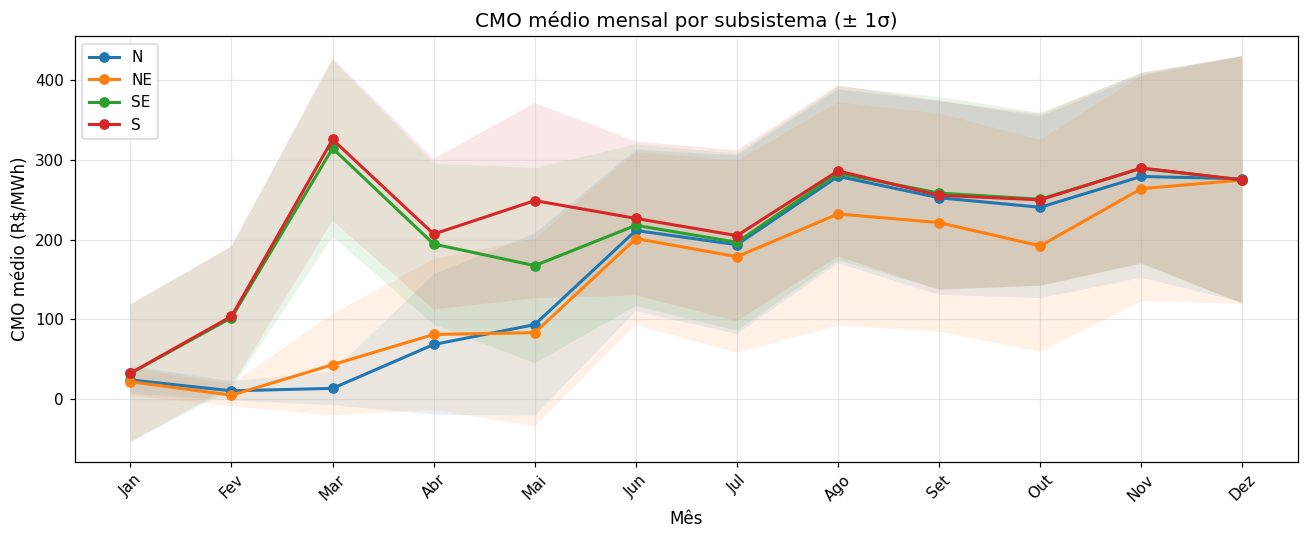

In [12]:
monthly_stats = (cmo_h_m.groupby(["mes", "id_subsistema"])["cmo_h"]
                 .agg(["mean", "median", "std", "min", "max"])
                 .round(2)
                 .reset_index())

# Tabela resumo
for ss in SUBSYS_ORDER:
    sub = monthly_stats[monthly_stats["id_subsistema"] == ss].set_index("mes")
    sub.index = [MESES_PT.get(m, m) for m in sub.index]
    print(f"\n{'='*55}")
    print(f"  CMO mensal — Subsistema {ss} (R$/MWh)")
    print(f"{'='*55}")
    display(sub[["mean", "median", "std", "min", "max"]])

# Gráfico comparativo entre subsistemas
fig, ax = plt.subplots(figsize=(12, 5))
for ss in SUBSYS_ORDER:
    sub = monthly_stats[monthly_stats["id_subsistema"] == ss].sort_values("mes")
    ax.plot(sub["mes"], sub["mean"], marker="o", linewidth=2, label=ss)
    ax.fill_between(sub["mes"],
                    sub["mean"] - sub["std"],
                    sub["mean"] + sub["std"],
                    alpha=0.1)

ax.set_xticks(range(1, 13))
ax.set_xticklabels([MESES_PT[m] for m in range(1, 13)], rotation=45)
ax.set_xlabel("Mês")
ax.set_ylabel("CMO médio (R$/MWh)")
ax.set_title("CMO médio mensal por subsistema (± 1σ)")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

### 4.2 CMO Semanal por Patamar: Spread Leve–Pesada ao Longo do Ano

O spread entre os patamares leve e pesado indica quanto o sistema "paga a mais" nas horas de pico em relação às horas de vale. Um spread alto sugere inflexibilidade do sistema para responder a picos de demanda.

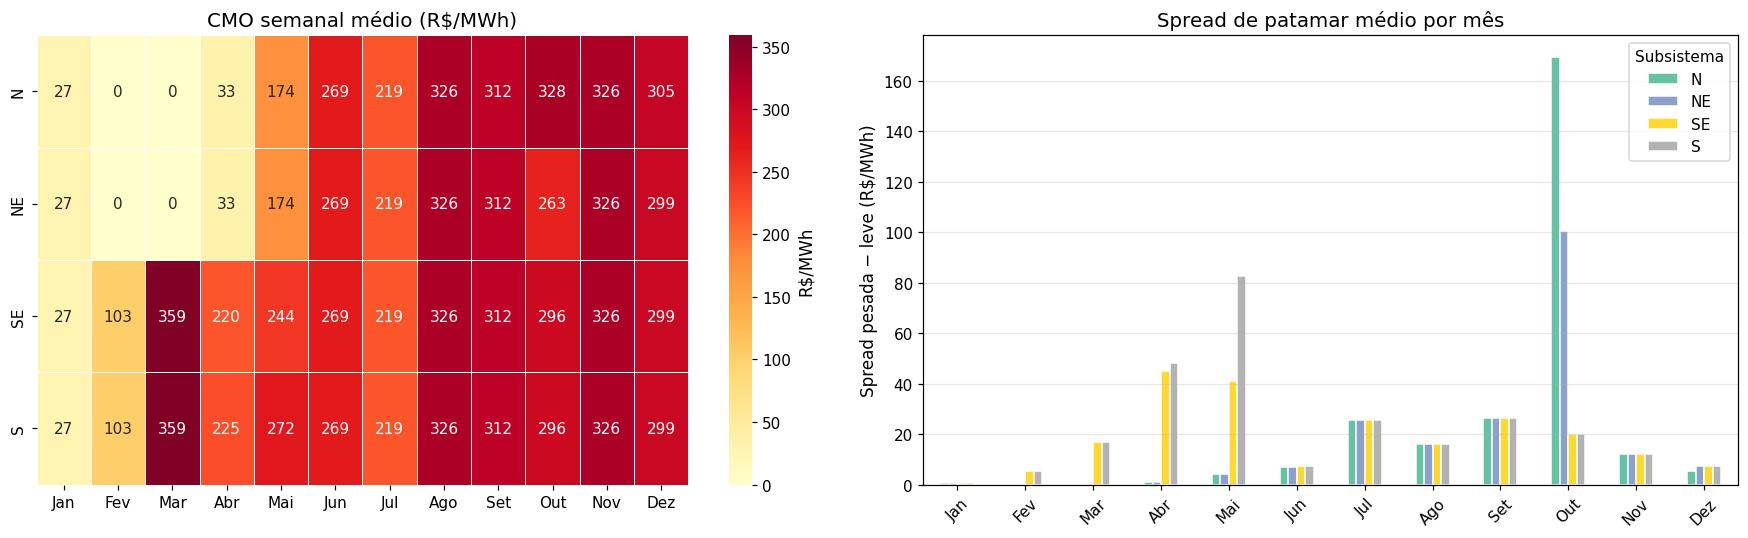

In [13]:
cmo_sem_m = cmo_sem.copy()
cmo_sem_m["mes"] = cmo_sem_m["din_instante"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Patamar médio por mês (heatmap subsistema × mês)
ax = axes[0]
piv = cmo_sem_m.pivot_table(index="id_subsistema", columns="mes",
                             values="cmo_medio", aggfunc="mean")
piv = piv.reindex(SUBSYS_ORDER)
piv.columns = [MESES_PT.get(m, m) for m in piv.columns]
sns.heatmap(piv, annot=True, fmt=".0f", cmap="YlOrRd", ax=ax,
            linewidths=0.5, cbar_kws={"label": "R$/MWh"})
ax.set_title("CMO semanal médio (R$/MWh)")
ax.set_ylabel("")

# Spread pesada − leve por mês
ax = axes[1]
spread_month = cmo_sem_m.groupby(["mes", "id_subsistema"])["spread_pesada_leve"].mean().unstack()
spread_month = spread_month.reindex(columns=SUBSYS_ORDER)
spread_month.index = [MESES_PT.get(m, m) for m in spread_month.index]
spread_month.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="white")
ax.set_ylabel("Spread pesada − leve (R$/MWh)")
ax.set_title("Spread de patamar médio por mês")
ax.legend(title="Subsistema")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")

fig.tight_layout()
plt.show()

## 5. CMO vs. Variáveis Físicas do Sistema

O preço marginal é determinado pela interação entre oferta e demanda. Nesta seção cruzamos o CMO horário com as variáveis do painel (demanda, geração renovável, hidrelétrica, térmica, intercâmbio) para entender os drivers de preço.

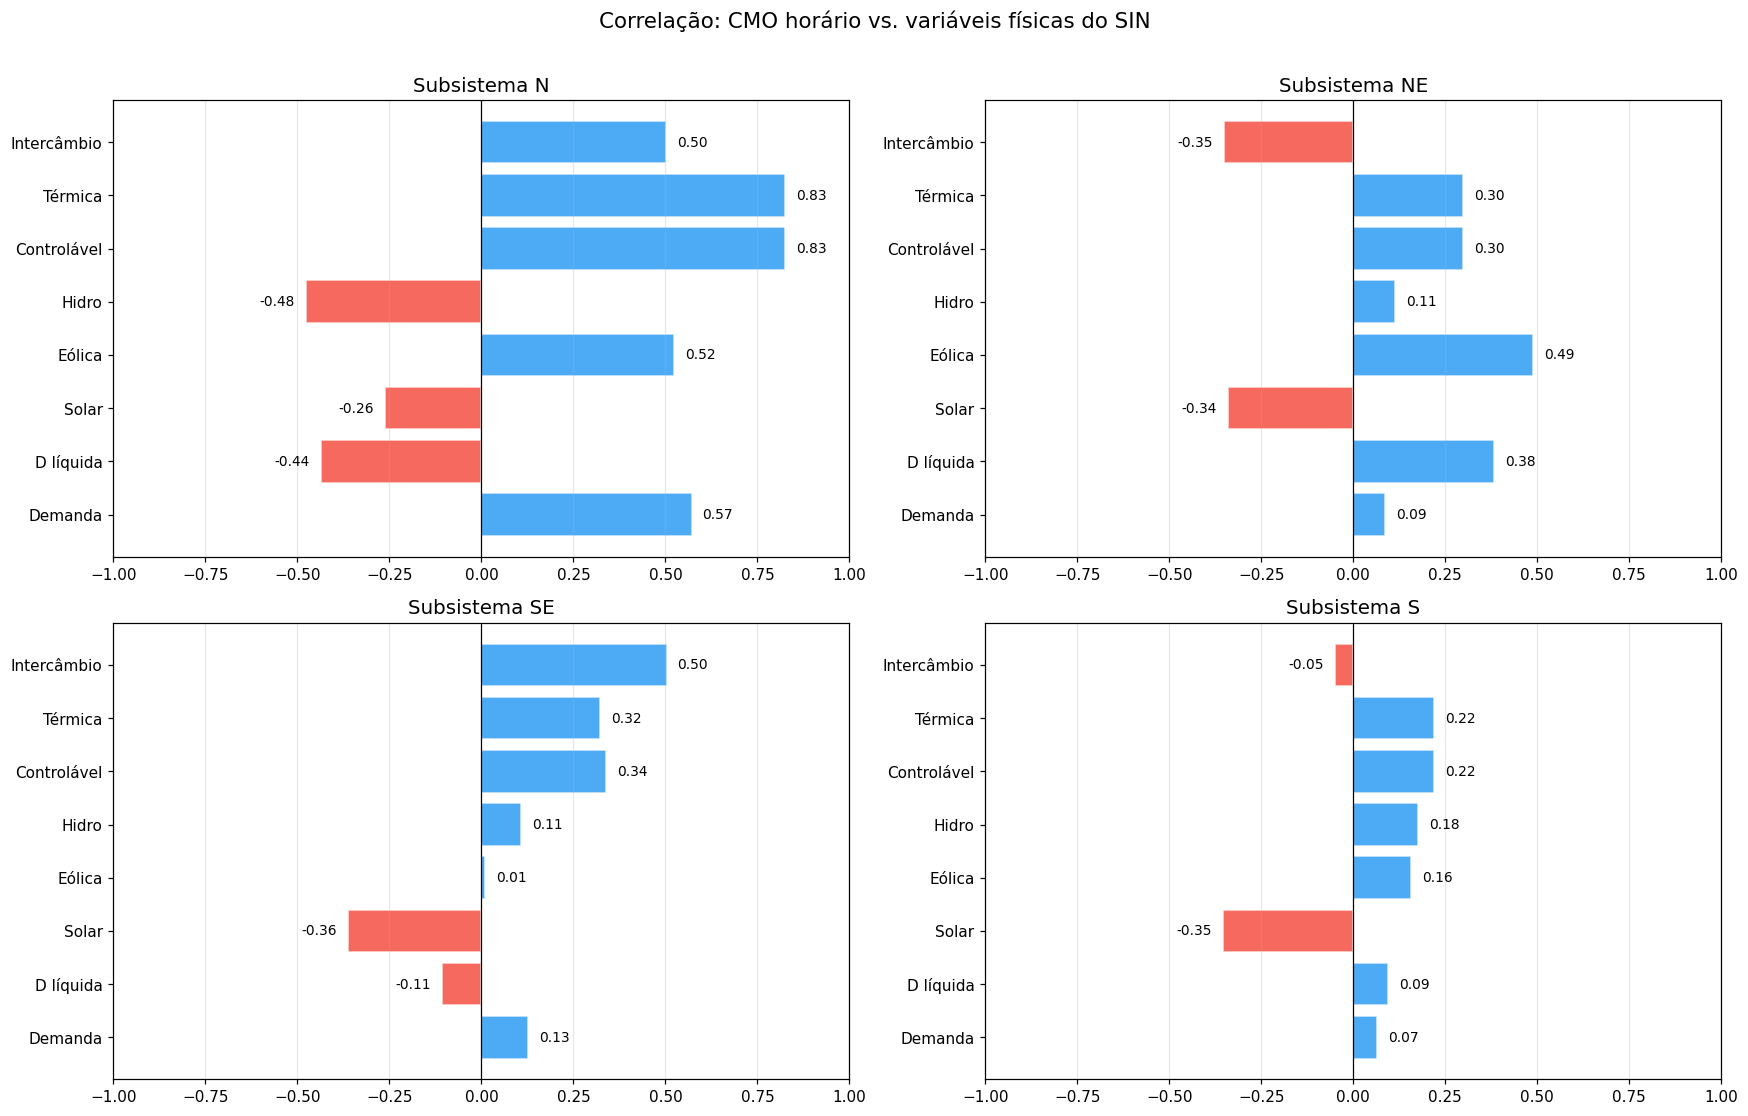

In [14]:
# Correlação CMO vs. variáveis físicas
phys_cols = ["D", "D_net", "gs", "gr", "gh", "gn_obs", "g_th_obs", "x_int"]
phys_labels = ["Demanda", "D líquida", "Solar", "Eólica", "Hidro",
               "Controlável", "Térmica", "Intercâmbio"]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, ss in zip(axes.flat, SUBSYS_ORDER):
    sub = panel_cmo[panel_cmo["id_subsistema"] == ss][phys_cols + ["cmo_h"]].dropna()
    if len(sub) < 10:
        ax.set_title(f"[{ss}] Dados insuficientes")
        continue

    corrs = sub[phys_cols].corrwith(sub["cmo_h"]).values
    colors_bar = ["#F44336" if c < 0 else "#2196F3" for c in corrs]

    bars = ax.barh(phys_labels, corrs, color=colors_bar, edgecolor="white", alpha=0.8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_title(f"Subsistema {ss}")
    ax.grid(True, alpha=0.3, axis="x")

    for bar, val in zip(bars, corrs):
        ax.text(val + (0.03 if val >= 0 else -0.03), bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)

fig.suptitle("Correlação: CMO horário vs. variáveis físicas do SIN", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### 5.1 Scatter: CMO vs. Geração Térmica e Demanda Residual

A geração térmica é o principal driver de custo marginal. A demanda residual ($D_{net} - g^s - g^r - g^h$) determina quanto de térmica é necessário, logo deve correlacionar fortemente com o CMO.

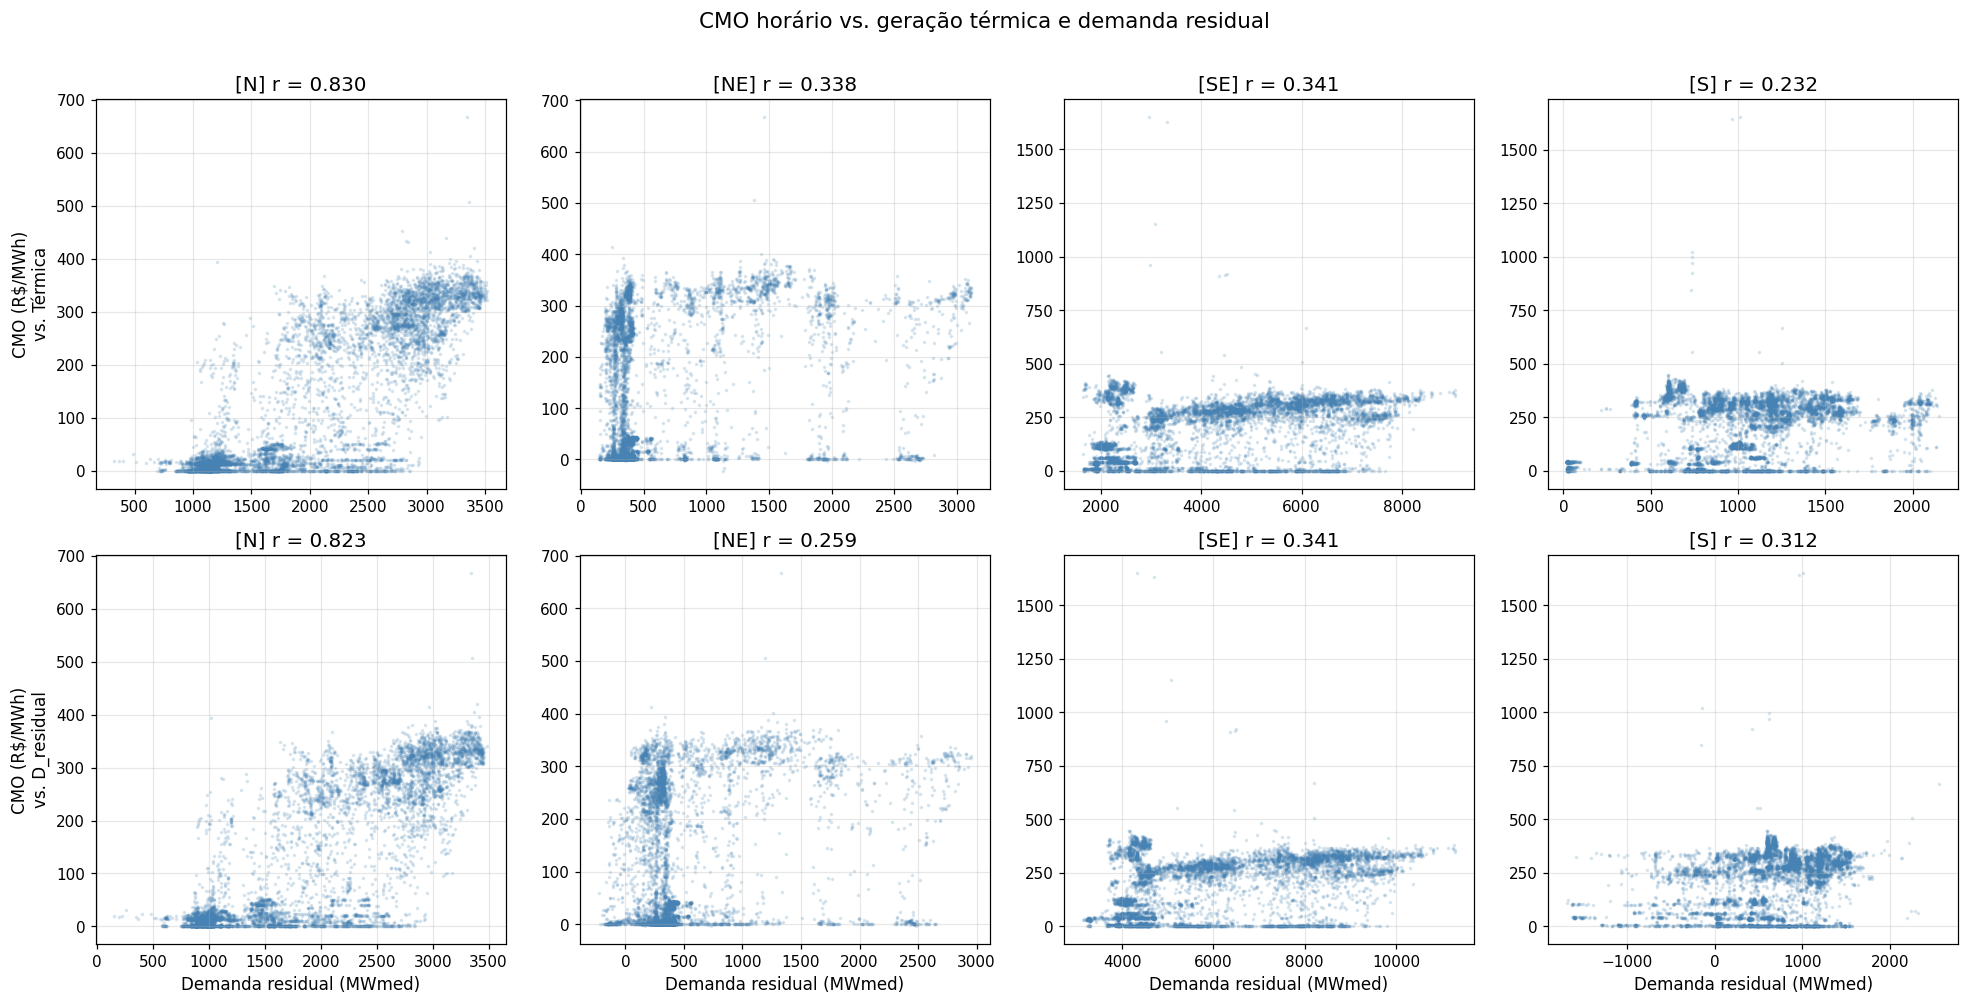

In [15]:
panel_cmo["D_residual"] = panel_cmo["D_net"] - (panel_cmo["gs"] + panel_cmo["gr"] + panel_cmo["gh"])

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for col_idx, (var, xlabel) in enumerate([("g_th_obs", "Geração térmica (MWmed)"),
                                          ("D_residual", "Demanda residual (MWmed)")]):
    for row_idx, ss in enumerate(SUBSYS_ORDER):
        ax = axes[col_idx][row_idx]
        sub = panel_cmo[panel_cmo["id_subsistema"] == ss][[var, "cmo_h"]].dropna()
        if len(sub) < 10:
            ax.set_title(f"[{ss}] Insuf.")
            continue

        ax.scatter(sub[var], sub["cmo_h"], s=2, alpha=0.15, color="steelblue")
        r = sub[var].corr(sub["cmo_h"])
        ax.set_title(f"[{ss}] r = {r:.3f}")
        ax.set_xlabel(xlabel if col_idx == 1 else "")
        ax.set_ylabel("CMO (R$/MWh)" if row_idx == 0 else "")
        ax.grid(True, alpha=0.3)

axes[0][0].set_ylabel("CMO (R$/MWh)\nvs. Térmica")
axes[1][0].set_ylabel("CMO (R$/MWh)\nvs. D_residual")
fig.suptitle("CMO horário vs. geração térmica e demanda residual", fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

### 5.2 CMO Mensal vs. Mix de Geração

Relação entre o CMO médio mensal e a participação de cada fonte na geração total, revelando como a composição do mix energético determina o custo marginal.

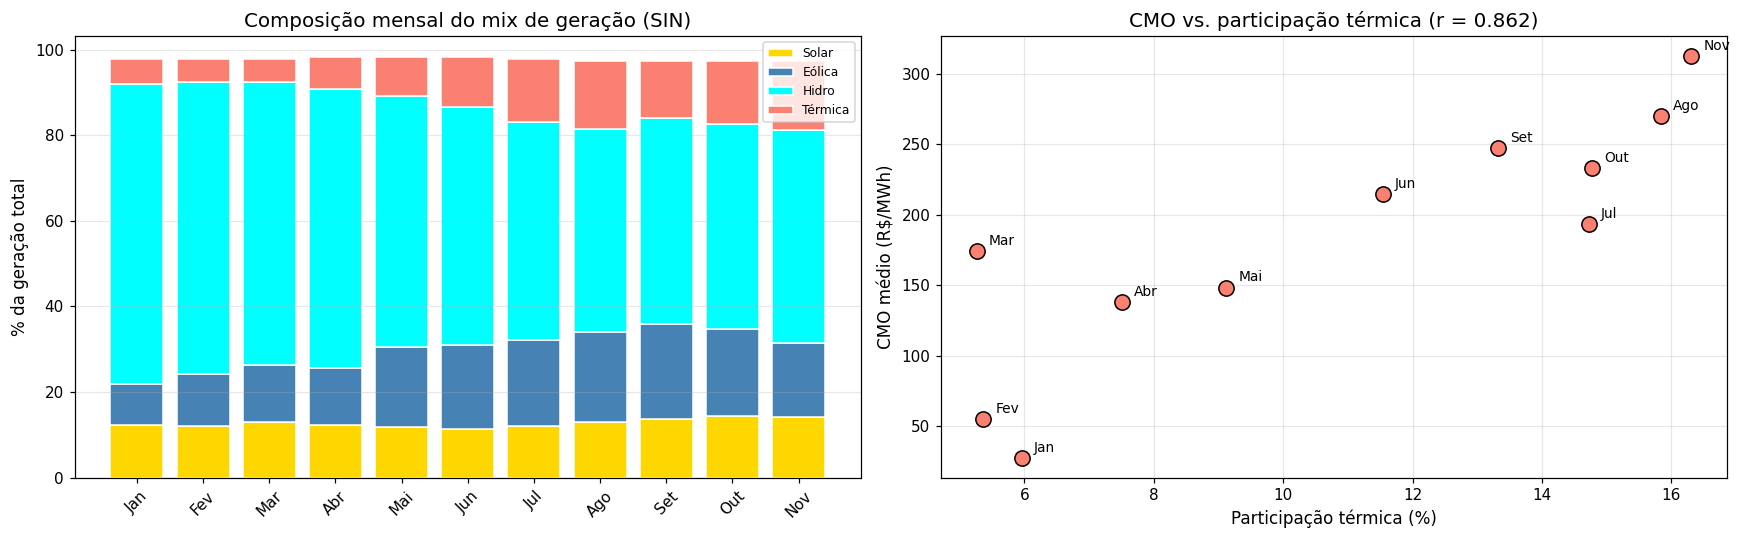

In [16]:
panel_cmo["mes"] = panel_cmo["din_instante"].dt.month
panel_cmo["gen_total"] = panel_cmo["gs"] + panel_cmo["gr"] + panel_cmo["gh"] + panel_cmo["gn_obs"]

monthly_mix = panel_cmo.groupby("mes").agg(
    cmo_medio=("cmo_h", "mean"),
    pct_solar=("gs", "sum"),
    pct_eolica=("gr", "sum"),
    pct_hidro=("gh", "sum"),
    pct_termica=("g_th_obs", "sum"),
    gen_total=("gen_total", "sum"),
).reset_index()

for col in ["pct_solar", "pct_eolica", "pct_hidro", "pct_termica"]:
    monthly_mix[col] = monthly_mix[col] / monthly_mix["gen_total"] * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar do mix
x = np.arange(len(monthly_mix))
bottom = np.zeros(len(monthly_mix))
bar_data = [
    ("pct_solar", "Solar", "gold"),
    ("pct_eolica", "Eólica", "steelblue"),
    ("pct_hidro", "Hidro", "cyan"),
    ("pct_termica", "Térmica", "salmon"),
]
for col, label, color in bar_data:
    ax1.bar(x, monthly_mix[col], bottom=bottom, label=label, color=color, edgecolor="white", width=0.8)
    bottom += monthly_mix[col].values

ax1.set_xticks(x)
ax1.set_xticklabels([MESES_PT[m] for m in monthly_mix["mes"]], rotation=45)
ax1.set_ylabel("% da geração total")
ax1.set_title("Composição mensal do mix de geração (SIN)")
ax1.legend(loc="upper right", fontsize=8)
ax1.grid(True, alpha=0.3, axis="y")

# CMO vs. % térmica
ax2.scatter(monthly_mix["pct_termica"], monthly_mix["cmo_medio"],
            s=100, color="salmon", edgecolors="black", zorder=5)
for _, row in monthly_mix.iterrows():
    ax2.annotate(MESES_PT[int(row["mes"])],
                 (row["pct_termica"], row["cmo_medio"]),
                 textcoords="offset points", xytext=(8, 4), fontsize=9)

r = monthly_mix["pct_termica"].corr(monthly_mix["cmo_medio"])
ax2.set_xlabel("Participação térmica (%)")
ax2.set_ylabel("CMO médio (R$/MWh)")
ax2.set_title(f"CMO vs. participação térmica (r = {r:.3f})")
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 6. Resumo

Síntese dos principais achados sobre o comportamento de preços no SIN em 2025.

In [17]:
print("=" * 70)
print("RESUMO DA ANÁLISE DE PREÇOS — CMO SIN 2025")
print("=" * 70)

for ss in SUBSYS_ORDER:
    sub = cmo_h[cmo_h["id_subsistema"] == ss]["cmo_h"].dropna()
    print(f"\n[{ss}] CMO horário:")
    print(f"  Média: {sub.mean():.2f} R$/MWh  |  Mediana: {sub.median():.2f} R$/MWh")
    print(f"  Min: {sub.min():.2f}  |  Max: {sub.max():.2f}  |  σ: {sub.std():.2f}")
    print(f"  Horas com CMO = 0: {(sub == 0).sum()} ({(sub == 0).mean()*100:.1f}%)")

# CMO semanal
print(f"\nCMO semanal (DECOMP):")
for ss in SUBSYS_ORDER:
    sub = cmo_sem[cmo_sem["id_subsistema"] == ss]
    print(f"  [{ss}] Médio: {sub['cmo_medio'].mean():.1f}  |  "
          f"Leve: {sub['cmo_leve'].mean():.1f}  |  "
          f"Média: {sub['cmo_media'].mean():.1f}  |  "
          f"Pesada: {sub['cmo_pesada'].mean():.1f} R$/MWh")

# Estacionariedade
print(f"\nEstacionariedade (ADF):")
for _, row in adf_df.iterrows():
    print(f"  [{row['subsistema']}] {row['conclusao']} (p={row['p_valor']:.6f})")

print("\n✓ Análise de preços concluída.")

RESUMO DA ANÁLISE DE PREÇOS — CMO SIN 2025

[N] CMO horário:
  Média: 162.98 R$/MWh  |  Mediana: 177.01 R$/MWh
  Min: -0.06  |  Max: 2113.39  |  σ: 147.31
  Horas com CMO = 0: 282 (3.2%)

[NE] CMO horário:
  Média: 150.86 R$/MWh  |  Mediana: 132.64 R$/MWh
  Min: -38.19  |  Max: 2113.39  |  σ: 146.55
  Horas com CMO = 0: 1107 (12.7%)

[SE] CMO horário:
  Média: 216.05 R$/MWh  |  Mediana: 262.85 R$/MWh
  Min: -0.04  |  Max: 2113.39  |  σ: 138.04
  Horas com CMO = 0: 614 (7.0%)

[S] CMO horário:
  Média: 226.33 R$/MWh  |  Mediana: 271.97 R$/MWh
  Min: -0.08  |  Max: 2113.39  |  σ: 135.80
  Horas com CMO = 0: 202 (2.3%)

CMO semanal (DECOMP):
  [N] Médio: 194.8  |  Leve: 187.9  |  Média: 193.5  |  Pesada: 212.2 R$/MWh
  [NE] Médio: 188.1  |  Leve: 179.5  |  Média: 193.1  |  Pesada: 197.4 R$/MWh
  [SE] Médio: 248.1  |  Leve: 240.3  |  Média: 252.2  |  Pesada: 259.1 R$/MWh
  [S] Médio: 251.2  |  Leve: 240.3  |  Média: 258.7  |  Pesada: 263.3 R$/MWh

Estacionariedade (ADF):
  [N] ESTACIONÁRIA